# Portfolio 4: Controller for a Mobile Robot (Open-ended Mini Project)
> Design and develop a controller for manually driving your mobile robot.

Type:
- [ ] Extra Credit Activities
- [x] Portfolio (Semester Project Group)

Student information
  - Student name: Anders Pramvig, Anders Jacobsen, Emil O'Kane, Magnus Bruus og Victor Süberkrüb
  - Student mail: apram25@student.sdu.dk, anjac25@student.sdu.dk, emouk25@student.sdu.dk, mabru25@student.sdu.dk, visub25@student.sdu.dk

*Group number:* 5

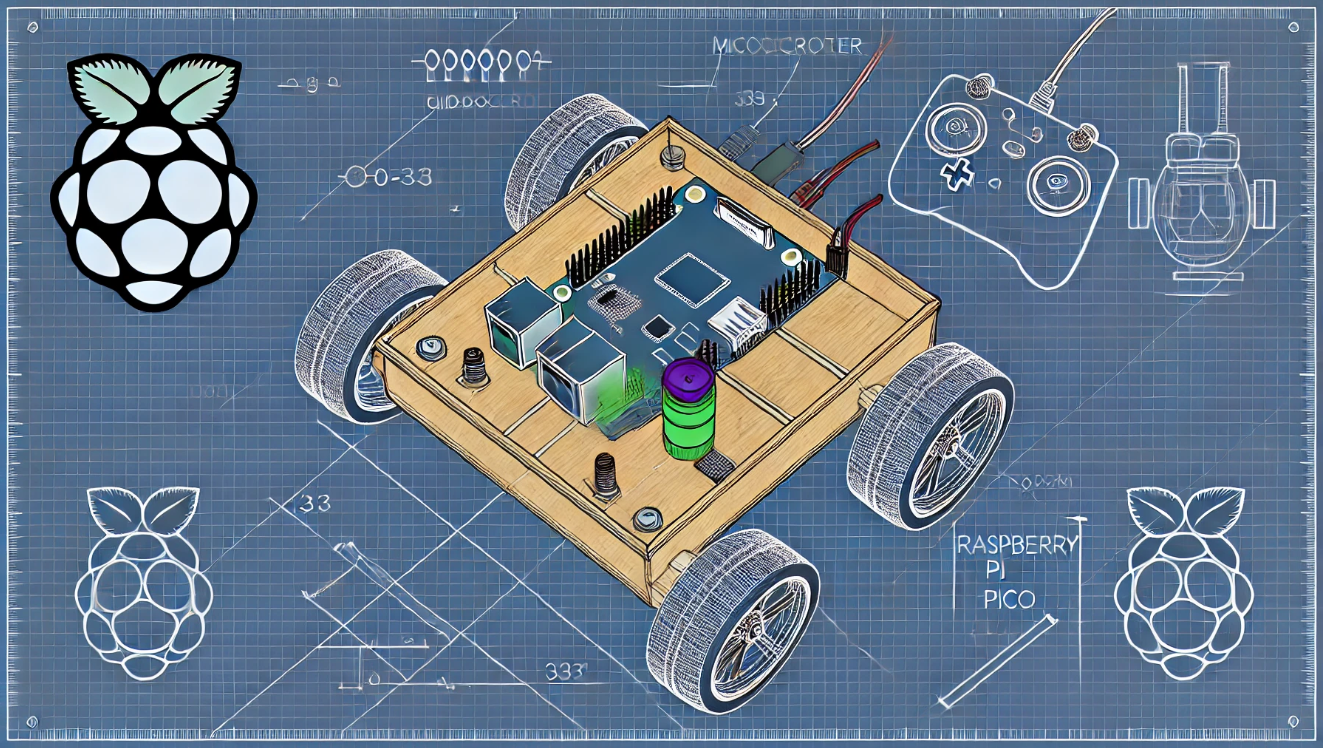

This portfolio is an open-ended project in which you must design and develop a prototype based on a set of outlined functional requirements.

Your assignment is to design and build a functional prototype of a controller that enables manual navigation of your mobile robot. The goal is to create an intuitive control interface that meets the following requirements: command the mobile robot's movement, adjust its speed. Furthermore, you must ensure a safe operation by implementing a kill-switch function.

Your controller must support directional commands, allowing the robot to move forward, backward, and turn left or right. Since this is an open-ended project, you have flexibility in determining how these movements will be executed; whether through discrete steps, continuous motion, or a combination of both. Additionally, speed control is essential, with a clear visual indicator to display the current speed level, such as LEDs, an OLED display, or, optionally, a graphical user interface.

The controller must be a separate hardware device. Therefore, as part of the mini-project, you will also need to decide on the communication interface between the controller and the robot.

When working with robots, safety is a top priority, so your design must include an emergency stop feature to immediately halt the robot when necessary.

## Requirements

The objective of the portfolio is for you to design and develop a functional prototype of a controller for manually navigating your mobile robot.

The controller must fulfill the following design requirements:

* **Movement commands**  
  * Your controller must be able to command the robot to move in all four main directions:  
    * forward,  
    * backward,  
    * turn left, and  
    * turn right.  
  * It is up to you to decide if your implementation should support:  
    * Discrete motion steps (e.g., moving a set distance forward or backward, or turning a set angle to the left or right),
      * (*optional feature*) Consider if the distance and angle is already predifed or it should be an user-input of some sort
    * Continuous motion control (e.g., moving in a specified direction until stopped based on user-input), or  
    * (*optional feature*) support both.

* **Speed Adjustment**  
  * Your controller must include the ability to adjust the speed of the mobile robot.

* **User Interface (Control input)**  
  * The controller should have ***an intuitive user interface*** that allows for easy manipulation of the robot's movement and speed.  
    - The choice and number of input methods are yours; they could include:  
      * physical buttons,  
      * potentiometers,  
      * joystick controls, or  
      * (*optional feature*) remote applications (e.g., mobile app or web-based interface).  
  * Implement a ***visual indicator*** that clearly shows the current speed level of your mobile robot. Options may include:  
      * LEDs,  
      * an OLED display, or  
      * (*optional feature*) a graphical user interface.  
  * (*optional feature*) Implement indicators for *displaying other relevant information* about your mobile robot, e.g., its current movement or status.

* **Data communication**  
  * Establish reliable communication between your controller and the mobile robot to ensure that commands are transmitted and received correctly.  
    - The choice of data communication method is yours; it could include:  
      * Direct integration with the mobile robot's Raspberry Pi Pico GPIOs.  
      * ***Serial Communication***: Use serial communication, for example, between two Raspberry Pi Picos; one on the mobile robot and one on the controller.  
        - Consider the type of connection (e.g., UART or I2C) and the communication method (e.g., simplex for one-way communication or duplex if feedback is required from the mobile robot to the controller).  
      * (*optional feature*) ***Remote Control***: Implement Bluetooth or Wi-Fi communication for wireless control.

* **Safety and Emergency Stop Functionality**  
  * Implement a **"kill switch"** or **emergency stop** mechanism that can immediately halt the robot's movement when necessary.  
  * The "kill switch" doesn't necessarily need to be integrated into the controller itself.  
    - It may even be more robust to implement it directly on the mobile robot, which can simplify the overall design and reduce the complexity of the controller.


# Hand-in (Deadline: 30/11, 23:59)

## Video
Make a ***1-minute and 30-second*** video showcasing your working prototype. In the video:
  * **Demonstrate the key functionalities:** Show the main features of your controller, including working movement commands, speed adjustment, indicators, and the emergency stop feature.
  * **Explain design decisions:** Briefly discuss the key design choices you made, such as:
    * *Choice of communication* method (e.g., wired, Bluetooth, Wi-Fi).
    * *Choice of user interface* design and input methods (e.g., buttons, joystick).
    * *Choice of indicators* (e.g., LEDs, OLED screen) and how they help communicate speed or other robot states.
  * (*optional*) Mention any *specific challenges* you encountered and how you resolved them, or flaws in the system that you are aware of but didn’t fix due to time constraints.

Keep the video concise, clear, and focused on demonstrating how your final solution meets the requirements for the mini project.

Link to video: **(https://youtu.be/JKWzpLtWZrY)**


## Source code



Main til controlleren

In [ ]:
import network
import socket
import time
from machine import ADC, Pin, I2C
import math
import ssd1306

SSID = "Victor's Galaxy A52"
PASSWORD = "ebpm3056"
PORT = 1234

# Connect server Pico to Wi-Fi
wlan = network.WLAN(network.STA_IF)
wlan.active(True)
wlan.connect(SSID, PASSWORD)

# Wait for connection
for _ in range(20):
    if wlan.isconnected():
        break
    time.sleep(0.5)

if not wlan.isconnected():
    print("Failed to connect to Wi-Fi")
    raise SystemExit

print("Server Wi-Fi connected, IP:", wlan.ifconfig()[0])

# Setup TCP server
addr = socket.getaddrinfo("0.0.0.0", PORT)[0][-1] 
server_socket = socket.socket()
server_socket.bind(addr)
server_socket.listen(1)
print(f"Server listening on port {PORT}...")


# Defining the adc's for x and y
adcX = ADC(28)
adcY = ADC(27)
i2c = I2C(0, scl=Pin(17), sda=Pin(16))
oled = ssd1306.SSD1306_I2C(128, 64, i2c)
oled_update_counter = 0
killswitch = Pin(10, Pin.IN, Pin.PULL_UP)

while True:
    try:
        print("Waiting for client to connect...")
        conn, client_addr = server_socket.accept()
        print(f"Client connected from {client_addr}")
        
        

        while True:
            try:
                print(killswitch.value())
                if killswitch.value() == 0:
                    break                    
                valueX = adcX.read_u16()
                valueY = adcY.read_u16()
                print(valueX,valueY)

                if valueX == 65535:
                    valueX = 2
                elif valueX >=50000:
                    valueX = 1
                elif valueX <= 25300:
                    valueX = -2
                elif valueX <= 46000:
                    valueX = -1
                else:
                    valueX = 0
                    
                if valueY == 65535:
                    valueY = 2
                elif valueY >=50000:
                    valueY = 1
                elif valueY <= 25300:
                    valueY = -2
                elif valueY <= 46000:
                    valueY = -1
                else:
                    valueY = 0
                
                #Send x and y values
                message =  f"{valueX},{valueY}\n"  
                conn.send((message).encode())
                print(f"Sent: {message}")
                
                
                oled_update_counter += 1
                if oled_update_counter >= 10:
                    oled_update_counter = 0
                    speed="Stopped"
                    if abs(valueY)==1:
                        speed="Slow"
                    elif abs(valueY)==2:
                        speed="Fast"
                    elif abs(valueX)==2:
                        speed="Fast"
                    elif abs(valueX)==1:
                        speed="Slow"
                
                    oled.fill(0)
                    oled.text("Robot Speed:", 0, 0)
                    oled.text("{}".format(speed), 0, 20)
                    oled.show()
                time.sleep(0.2)

            except OSError:
                print(f"Client {client_addr} disconnected")
                conn.close()
                break

    except KeyboardInterrupt:
        print("Server closed.")
        break


Main til robot

In [ ]:
import network
import socket
import time
from stepper_motor import StepperMotor
from p4_differential_drive import DifferentialDrive

SSID = "Victor's Galaxy A52"
PASSWORD = "ebpm3056"
SERVER_IP = "10.139.255.177" 
SERVER_PORT = 1234

# Connect client Pico to Wi-Fi
wlan = network.WLAN(network.STA_IF)
wlan.active(True)

def connect_wifi():
    wlan.connect(SSID, PASSWORD)
    for _ in range(20):
        if wlan.isconnected():
            print("Client Wi-Fi connected, IP:", wlan.ifconfig()[0])
            return True
        time.sleep(0.5)
    return False

def connect_server():
    while True:
        try:
            s = socket.socket()
            s.connect((SERVER_IP, SERVER_PORT))
            print(f"Connected to server at {SERVER_IP}:{SERVER_PORT}")
            
            return s
        except OSError:
            print("Server unreachable, retrying in 2s...")
            time.sleep(2)
            
#Defining the pins and motors
pins_right = [0,1,2,3]
pins_left = [4,5,6,7]

left = StepperMotor(pins_left, "MICRO", 40, 18000, 32, 200)
right = StepperMotor(pins_right, "MICRO", 40, 18000, 32, 200)
diff = DifferentialDrive(left, right)

# Main loop
while True:
    if not wlan.isconnected():
        print("Connecting to Wi-Fi...")
        if not connect_wifi():
            print("Failed to connect, retrying in 2s...")
            time.sleep(2)
            continue

    s = connect_server()

    try:
        s.settimeout(0) 
        buffer = ""
        lastX = 0
        lastY = 0

        while True:
            try:
                data = s.recv(1024)

                if data:  
                    buffer += data.decode()

                    while "\n" in buffer:
                        line, buffer = buffer.split("\n", 1)

                        values = line.split(",")
                        if len(values) == 2:
                            try:
                                lastX = int(values[0])
                                lastY = int(values[1])
                                print(lastX, lastY)
                            except:
                                pass  
            except OSError:
                # No data available 
                pass

            #Movement
            if lastY == 2 :
                diff.set_microsteps(32)
                diff.forward(4)
            elif lastY == 1 :
                diff.set_microsteps(80)
                diff.forward(4)
            elif lastY == -2 :
                diff.set_microsteps(32)
                diff.backward(4)
            elif lastY == -1 :
                diff.set_microsteps(80)
                diff.backward(4)
            elif lastX == 2 :
                diff.set_microsteps(32)
                diff.turn_in_place_steps("left", 4)
            elif lastX == 1 :
                diff.set_microsteps(80)
                diff.turn_in_place_steps("left", 4)
            elif lastX == -2:
                diff.set_microsteps(32)
                diff.turn_in_place_steps("right", 4)
            elif lastX == -1:
                diff.set_microsteps(80)
                diff.turn_in_place_steps("right", 4)
            
            
            else:
                time.sleep(0.005)


    except OSError as e:
        print("Connection error:", e)
        s.close()
        time.sleep(1)



The p4_differential_drive.py file used above

In [ ]:
from stepper_motor import StepperMotor
import math

class DifferentialDrive:
    def __init__(self, left, right):
        """
        Initialize the navigation system with two stepper motors.

        :param left: Instance of StepperMotor class for the left motor.
        :param right: Instance of StepperMotor class for the right motor.

        OTHER PARAMS?

        """

        self.left = left
        self.right = right

        
        self.stop()
    
    def move_one_stepper(self, steps, stepper):
        """
        Move either left or right stepper a certain amount of steps.
        
        :param steps (INT): Number of steps to turn
        :param stepper (STR): Stepper to turn
        
        """
        step_seq_len = len(self.left.step_sequence)
        if stepper == "left":
            for _ in range(steps):
                for i in range(step_seq_len):
                    self.left.set_step(self.left.step_sequence[i])
        elif stepper == "right":
            for _ in range(steps):
                for i in range(step_seq_len):
                    self.right.set_step(self.left.step_sequence[i])
        else:
            raise ValueError("Must be right or left")
            
            
    def move_one_stepper_backward(self, steps, stepper):
        """
        Move either left or right stepper a certain amount of steps.
        
        :param steps (INT): Number of steps to turn
        :param stepper (STR): Stepper to turn
        
        """
        step_seq_len = len(self.left.step_sequence)
        if stepper == "left":
            for _ in range(steps):
                for i in range(step_seq_len):
                    self.left.set_step(self.left.step_sequence[-i])
        elif stepper == "right":
            for _ in range(steps):
                for i in range(step_seq_len):
                    self.right.set_step(self.left.step_sequence[-i])
        else:
            raise ValueError("Must be right or left")        
    
    def forward(self, steps):
        """
        Move both stepper motors in the forward direction
        
        :param steps (INT): Number of steps to turn
        
        """
        step_seq_len = len(self.left.step_sequence)
        for _ in range(steps):
            for i in range(step_seq_len):
                self.left.set_step(self.left.step_sequence[i])
                self.right.set_step(self.right.step_sequence[i])
        self.stop()

    def backward(self, steps):
        """
        Move both stepper motors in the backward direction
        
        :param steps (INT): Number of steps to turn
        
        """
        step_seq_len = len(self.left.step_sequence)
        for _ in range(steps):
            for i in range(step_seq_len):
                self.left.set_step(self.left.step_sequence[-i])
                self.right.set_step(self.right.step_sequence[-i])
        self.stop()
        
    def stop(self):
        """
        Stop both stepper motors. 
        
        """
        self.left.stop()
        self.right.stop()
    
    def cm_to_steps(self, distance_cm):
        """
        Convert a distance in centimeters to the corresponding number of motor steps.
        :param distance_cm (INT): Distance to move in centimeters.
        :return: Number of steps corresponding to the given distance.
        """

        # --> wheel_circumference_cm: 

        wheel_diameter_cm = 8.7  # Example diameter in cm
        circumference_cm = 2 * math.pi * (wheel_diameter_cm / 2)

        # --> steps_per_revolution:
        step_sequences_per_revolution = 50  # Example value, adjust as needed

         # 1) Calculate the distance per step
        distance_per_step_cm = circumference_cm / step_sequences_per_revolution

        # 2) Calculate the number of steps
        steps = int(distance_cm / distance_per_step_cm)
        
        #Print for debugging
        #print(f"Distance per step: {distance_per_step_cm} cm")

        # Return the calculated number of steps based on the distance
        return steps
        

    def move_distance(self, direction, distance_cm):
        """
        Move the robot forward or backward a specific distance in centimeters.

        :param distance_cm: Distance to move in centimeters.
        :param direction: Direction to move, either 'forward' or 'backward'.
        """

        steps = self.cm_to_steps(distance_cm)
        if direction == "forward":
            self.forward(steps)
        
        if direction == "backward":
            self.backward(steps)

        self.stop()

    def turn_steps(self, direction, steps_for_rotation):
        """
        Turns the robot a given number of steps in a specified direction.
        
        :param direction (STR): The direction we want to move in.
        :param steps_for_rotation (INT): Amount of steps we want to move.
        """
        
        if direction == "right":
            self.move_one_stepper(steps_for_rotation, "left")
            
        elif direction == "left":
            self.move_one_stepper(steps_for_rotation, "right")
        else:
            raise ValueError("Must be right or left")
        self.stop()
        
    def turn_steps_backward(self, direction, steps_for_rotation):
        """
        Turns the robot a given number of steps in a specified direction.
        
        :param direction (STR): The direction we want to move in.
        :param steps_for_rotation (INT): Amount of steps we want to move.
        """
        
        if direction == "right":
            self.move_one_stepper_backward(steps_for_rotation, "left")
            
        elif direction == "left":
            self.move_one_stepper_backward(steps_for_rotation, "right")
        else:
            raise ValueError("Must be right or left")
        self.stop()
        
    def turn_degrees(self, direction, degrees):
        """
        Turns the robot a given number of degrees in a specified direction
        
        :param direction (STR): The direction we want to turn in.
        :param degrees (INT): Amount of degrees we want to turn.
        """
        circumference = math.pi * 25
        distance = circumference/(360/degrees)
        steps = self.cm_to_steps(distance)*2
        
        if direction == "right":
            self.move_one_stepper(steps, "left")
            
        elif direction == "left":
            self.move_one_stepper(steps, "right")
        else:
            raise ValueError("Must be right or left")
        self.stop()

    def turn_in_place(self, direction, degrees):
        """
        Turns the robot around its axis in a given number of degrees
        
        :param direction (STR): The direction we want to turn in.
        :param degrees (INT): Amount of degrees we want to turn.

        """
        circumference = math.pi * 25
        distance = circumference/(360/degrees)
        steps = self.cm_to_steps(distance)
        
        if direction == "right":
            step_seq_len = len(self.left.step_sequence)
            for _ in range(steps):
                for i in range(step_seq_len):
                    self.left.set_step(self.left.step_sequence[i])
                    self.right.set_step(self.right.step_sequence[-i])
            self.stop()
            
        elif direction == "left":
            step_seq_len = len(self.left.step_sequence)
            for _ in range(steps):
                for i in range(step_seq_len):
                    self.left.set_step(self.left.step_sequence[-i])
                    self.right.set_step(self.right.step_sequence[i])
            self.stop()
        else:
            raise ValueError("Must be right or left")
        self.stop()
        
    def turn_in_place_steps(self, direction, steps):
        """
        Turns the robot around its axis in a given number of degrees
        
        :param direction (STR): The direction we want to turn in.
        :param degrees (INT): Amount of degrees we want to turn.

        """
        
        
        if direction == "right":
            step_seq_len = len(self.left.step_sequence)
            for _ in range(steps):
                for i in range(step_seq_len):
                    self.left.set_step(self.left.step_sequence[i])
                    self.right.set_step(self.right.step_sequence[-i])
            self.stop()
            
        elif direction == "left":
            step_seq_len = len(self.left.step_sequence)
            for _ in range(steps):
                for i in range(step_seq_len):
                    self.left.set_step(self.left.step_sequence[-i])
                    self.right.set_step(self.right.step_sequence[i])
            self.stop()
        else:
            raise ValueError("Must be right or left")
        self.stop()
        
        
    def set_microsteps (self, microsteps):
        self.left.set_microsteps(microsteps)
        self.right.set_microsteps(microsteps)
            



The stepper_motor.py file used above

In [ ]:
from machine import Pin, PWM
import time

class StepperMotor:
    def __init__(self, pins, step_mode="FULL", pwm_pct=15, frequency=16_000, micro_steps=32, steps_per_rev=200):
        """
        Initialize the stepper motor with given pins, PWM frequency, step mode, and steps per revolution.
        
        :param pins: List of GPIO pin numbers connected to the motor driver.
        :param step_mode: The stepping mode for the motor ("FULL", "HALF", or "MICRO").
        :param pwm_pct: PWM percentage for each motor coil (0 to 100).
        :param frequency: Frequency for the PWM signals in Hz.
        :param micro_steps: Number of micro-steps per full step (used in micro-stepping mode).
        :param [TODO: Implement RPM] steps_per_rev: Number of steps required for one full revolution (default is 200).
        """

        # Initialize PWM for each pin
        self.pins = [PWM(Pin(pin)) for pin in pins]
        
        # Motor parameters
        self.steps_per_rev = steps_per_rev  # Steps per revolution 

        # Set the PWM frequency for all pins
        self.set_frequency(frequency)
 
        # Calculate the PWM value from percentage (65535 is max for 16-bit)
        self.pwm_max = 65535
        self.pwm_val = int(self.pwm_max * pwm_pct / 100)
        self.micro_steps = micro_steps
        self.step_mode = step_mode.upper() # Ensure that is it uppercase letters
        
        # Initialize step counter to track the total number of step sequences
        self.step_counter = 0

        # Choose the step sequence based on the mode (FULL, HALF, or MICRO)
        if self.step_mode == "FULL":
            # Full-step sequence
            self.step_sequence = [
                [self.pwm_val, self.pwm_val, 0, 0],
                [0, self.pwm_val, self.pwm_val, 0],
                [0, 0, self.pwm_val, self.pwm_val],
                [self.pwm_val, 0, 0, self.pwm_val]
            ]
        elif self.step_mode == "HALF":
            # Half-step sequence
            self.step_sequence = [
                [self.pwm_val, 0, 0, 0],
                [self.pwm_val, self.pwm_val, 0, 0],
                [0, self.pwm_val, 0, 0],
                [0, self.pwm_val, self.pwm_val, 0],
                [0, 0, self.pwm_val, 0],
                [0, 0, self.pwm_val, self.pwm_val],
                [0, 0, 0, self.pwm_val],
                [self.pwm_val, 0, 0, self.pwm_val]
            ]
        elif self.step_mode == "MICRO":
            # Generate micro-stepping sequence
            self.step_sequence = self.generate_micro_step_sequence(self.pwm_val, self.micro_steps)
        
        else:
            # Invalid step mode handling
            self.stop_sequence = [0, 0, 0, 0]
            raise ValueError("Invalid step mode! Use 'FULL', 'HALF', or 'MICRO'.")
        
        # Print the step sequence for debugging purposes
        #self.print_step_sequence()
        
        # Sequence to stop the motor (no current in coils)
        self.stop_sequence = [0, 0, 0, 0]
        self._running = False
        
    def set_microsteps(self, microsteps):
        self.step_sequence = self.generate_micro_step_sequence(self.pwm_val, microsteps)

    def generate_micro_step_sequence(self, pwm_val, micro_steps):
        """
        Generates a step sequence for micro-stepping where PWM values increase and decrease alternately.
        
        :param pwm_val: Maximum PWM value for 16-bit resolution (65535).
        :param micro_steps: Number of micro-steps per full step.
        
        :return: A list of lists representing the step sequence for micro-stepping.
        """
        micro_step_size = pwm_val // micro_steps  # Define the micro step size
        step_sequence = []

        # Generate the step sequence for each phase
        # Phase 1: PWM on first pin, decreasing; PWM on second pin, increasing
        for i in range(micro_steps):
            pwm_1 = pwm_val - i * micro_step_size
            pwm_2 = i * micro_step_size
            step_sequence.append([pwm_1, pwm_2, 0, 0])

        # Phase 2: PWM on second pin, decreasing; PWM on third pin, increasing
        for i in range(micro_steps):
            pwm_2 = pwm_val - i * micro_step_size
            pwm_3 = i * micro_step_size
            step_sequence.append([0, pwm_2, pwm_3, 0])

        # Phase 3: PWM on third pin, decreasing; PWM on fourth pin, increasing
        for i in range(micro_steps):
            pwm_3 = pwm_val - i * micro_step_size
            pwm_4 = i * micro_step_size
            step_sequence.append([0, 0, pwm_3, pwm_4])

        # Phase 4: PWM on fourth pin, decreasing; PWM on first pin, increasing
        for i in range(micro_steps):
            pwm_4 = pwm_val - i * micro_step_size
            pwm_1 = i * micro_step_size
            step_sequence.append([pwm_1, 0, 0, pwm_4])

        return step_sequence

    def set_frequency(self, frequency):
        """
        Set the frequency for the PWM signals.

        :param frequency: The frequency of the PWM signal in Hz.
        """
        # Apply the given frequency to all pins
        for pin in self.pins:
            pin.freq(frequency)
    
    def move_stepper(self, steps, direction, delay_us):
        """
        
        """
        if direction == "forward":
            direction_step = 1
        elif direction == "backward":
            direction_step = -1
        else:
            raise ValueError("Direction must be 'forward' or 'backward'")
    
        steps = abs(steps)

        for _ in range(steps):
            for step in range(len(self.step_sequence))[::direction_step]:
                self.set_step(self.step_sequence[step])
                time.sleep_us(delay_us)
            
            self.step_counter += direction_step

        self.stop()

    def move_stepper_with_ramp(self, steps, direction, initial_delay_us=2000, final_delay_us=1000, ramp_steps=10):
        """
        Move the stepper motor with a speed ramp-up over a specified number of steps.
        
        :param steps: Number of steps to move.
        :param direction: Direction to move. "forward" for forward, "backward" for backward.
        :param initial_delay_us: Initial delay between steps in microseconds (for ramp-up start).
        :param final_delay_us: Final delay between steps in microseconds (for full speed).
        :param ramp_steps: Number of steps to use for ramping up/down.
        """
        # Determine direction of movement
        if direction == "forward":
            direction_step = 1
        elif direction == "backward":
            direction_step = -1
        else:
            raise ValueError("Direction must be 'forward' or 'backward'")
        
        # Move the motor step by step with ramping up speed
        steps = abs(steps)
        delay_increment = (initial_delay_us - final_delay_us) / ramp_steps  # Calculate delay decrement per ramp step
        
        # Ramp-up phase
        for i in range(ramp_steps):
            delay_us = initial_delay_us - i * delay_increment
            for step in range(len(self.step_sequence))[::direction_step]:
                self.set_step(self.step_sequence[step])
                time.sleep_us(int(delay_us))  # Apply delay and cast to int
    
        # Full-speed phase
        for _ in range(steps - 2 * ramp_steps):
            for step in range(len(self.step_sequence))[::direction_step]:
                self.set_step(self.step_sequence[step])
                time.sleep_us(final_delay_us)  # Apply full-speed delay
    
        # Ramp-down phase
        for i in range(ramp_steps):
            delay_us = final_delay_us + i * delay_increment
            for step in range(len(self.step_sequence))[::direction_step]:
                self.set_step(self.step_sequence[step])
                time.sleep_us(int(delay_us))  # Apply delay and cast to int
    
        self.stop()  # Stop the motor after completing the steps


    def ramp_up(self, steps, direction, initial_delay_us=2000, final_delay_us=1000, ramp_steps=10):
        """
        Move the stepper motor with a speed ramp-up over a specified number of steps, then continue at a steady speed.
        
        :param steps: Number of steps to move.
        :param direction: Direction to move. "forward" for forward, "backward" for backward.
        :param ramp_steps: Number of steps to use for ramping up to full speed.
        :param initial_delay_us: Initial delay between steps in microseconds (for ramp-up start).
        :param final_delay_us: Final delay between steps in microseconds (for full speed).
        """
        # Determine direction of movement
        if direction == "forward":
            direction_step = 1
        elif direction == "backward":
            direction_step = -1
        else:
            raise ValueError("Direction must be 'forward' or 'backward'")
        
        # Calculate delay decrement per ramp step
        delay_increment = (initial_delay_us - final_delay_us) / ramp_steps
        
        # Ramp-up phase
        for i in range(ramp_steps):
            delay_us = initial_delay_us - i * delay_increment
            for step in range(len(self.step_sequence))[::direction_step]:
                self.set_step(self.step_sequence[step])
                time.sleep_us(int(delay_us))  # Apply delay and cast to int

        # Steady-speed phase
        remaining_steps = steps - ramp_steps
        for _ in range(remaining_steps):
            for step in range(len(self.step_sequence))[::direction_step]:
                self.set_step(self.step_sequence[step])
                time.sleep_us(final_delay_us)  # Continue with final steady speed delay

        # Stop the motor after completing all steps, 
        # in case that no command is followed by this 
        self.stop()

    def ramp_down(self, steps, direction, initial_delay_us=2000, final_delay_us=1000, ramp_steps=10):
        """
        Move the stepper motor with a speed ramp-up over a specified number of steps.
        
        :param steps: Number of steps to move.
        :param direction: Direction to move. "forward" for forward, "backward" for backward.
        :param ramp_steps: Number of steps to use for ramping down from full speed.
        :param initial_delay_us: Initial delay between steps in microseconds (for ramp-up start).
        :param final_delay_us: Final delay between steps in microseconds (for full speed).
        """
        # Determine direction of movement
        if direction == "forward":
            direction_step = 1
        elif direction == "backward":
            direction_step = -1
        else:
            raise ValueError("Direction must be 'forward' or 'backward'")
        
        # Move the motor step by step with ramping up speed
        steps = abs(steps)
        delay_increment = (initial_delay_us - final_delay_us) / ramp_steps  # Calculate delay decrement per ramp step
    
        # Full-speed phase
        for _ in range(steps - ramp_steps):
            for step in range(len(self.step_sequence))[::direction_step]:
                self.set_step(self.step_sequence[step])
                time.sleep_us(final_delay_us)  # Apply full-speed delay
    
        # Ramp-down phase
        for i in range(ramp_steps):
            delay_us = final_delay_us + i * delay_increment
            for step in range(len(self.step_sequence))[::direction_step]:
                self.set_step(self.step_sequence[step])
                time.sleep_us(int(delay_us))  # Apply delay and cast to int
    
        self.stop()  # Stop the motor after completing the steps

    def print_step_sequence(self):
        """
        Print the current step sequence in a structured way.
        """

        # Print each step in the step sequence for debugging / validation
        print("--- Step Sequence ---")
        for idx, step in enumerate(self.step_sequence):
            print(f"Step {idx + 1}: {step}")
        print("-----    End    -----")

    def run_continuously(self, direction, delay_us=1000):
        """
        Run the stepper motor continuously in the specified direction.
        
        :param direction: Direction to move. "forward" for forward, "backward" for backward.
        :param delay_us: Delay between steps in microseconds.
        """
        # Determine direction of movement
        if direction == "forward":
            direction_step = 1
        elif direction == "backward":
            direction_step = -1
        else:
            raise ValueError("Direction must be 'forward' or 'backward'")
        
        # Run the motor until stopped
        self._running = True
        
        while self._running:
            for step in range(len(self.step_sequence))[::direction_step]:
                self.set_step(self.step_sequence[step])
                time.sleep_us(delay_us)  # Use microsecond delay
            
            self.step_counter += direction_step

    def run_continuously_in_secs(self, direction, seconds, delay_us=1000):
        """
        Run the stepper motor continuously in the specified direction for a set number of seconds.
        
        :param direction: Direction to move. "forward" for forward, "backward" for backward.
        :param seconds: Number of seconds to run the motor.
        :param delay_us: Delay between steps in microseconds.
        """
        # Determine direction of movement
        if direction == "forward":
            direction_step = 1
        elif direction == "backward":
            direction_step = -1
        else:
            raise ValueError("Direction must be 'forward' or 'backward'")
        
        start_time = time.time()  # Track the start time
        self._running = True

        print(f"Running the motor for {seconds} seconds.")
        
        # Run the motor for the specified duration
        while time.time() - start_time < seconds:
            for step in range(len(self.step_sequence))[::direction_step]:
                self.set_step(self.step_sequence[step])
                time.sleep_us(delay_us)  # Use microsecond delay
            
            self.step_counter += direction_step
        
        self.stop_running()
        print(f"Motor stopped after {seconds} seconds.")

    def stop_running(self):
        """
        Stop the continuous running of the stepper motor.
        """
        self._running = False  # Set running flag to False
        self.stop()  # Stop the motor

    def stop(self):
        """
        Set all PWM outputs to 0 to stop the motor.
        """
        self.set_step(self.stop_sequence)  # Apply stop sequence

    def set_step(self, step):
        """
        Set the stepper motor to a specific step.
 
        :param step: A list representing the step sequence.
        """
        # Apply the PWM values to each pin for the current step
        for pin in range(len(self.pins)):
            self.pins[pin].duty_u16(step[pin])


# Extra Credit Activities 3: Present your Mini Project (Deadline: 1/12, in-class)

> Take an active part in the presentation of your Mini Project about developing a controller for manully driving your mobile robot around

You will be presenting as a group, but points are given individually, depending on the level of participation from each group member.

Type:
- [x] Extra Credit Activities (Individual, 4 points)
- [ ] Portfolio